In [1]:
from QLBM import QLBM, collision, InitializeQC
import numpy as np
import matplotlib.pyplot as plt
import qiskit_aer
from qiskit import transpile

In [2]:
# Domain and grid setup
N_POINTS_X, N_POINTS_Y = 32, 32
x_0 = np.arange(N_POINTS_X)
y_0 = np.arange(N_POINTS_Y)
X, Y = np.meshgrid(x_0, y_0)  # Create a 2D grid

# Simulation parameters
TIMESTEPS = 35000
NUMBER_DISCRETE_VELOCITIES = 9  # D2Q9 lattice configuration

In [ ]:
Q = 9
Nx = N_POINTS_X-1
Ny = N_POINTS_Y-1
Re = 26
f_eq = np.zeros((Nx+1, Ny+1, Q))
f = np.zeros((Nx+1, Ny+1, Q))
f_star = np.zeros((Nx+1, Ny+1, Q))
fq = np.zeros((Nx+1, Ny+1, Q))
rho_0 = 1.0
rho = np.zeros((Nx+1, Ny+1))
u = np.zeros((Nx+1, Ny+1, 2))
e = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1], [1, 1], [-1, 1], [-1, -1], [1, -1]])
w = np.array([4.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/36, 1.0/36, 1.0/36, 1.0/36])

u_n = u[:, :, 0].copy()
v_n = u[:, :, 1].copy() 
u_t = np.zeros((Nx+3, Ny+3))
v_t = np.zeros((Nx+3, Ny+3))

uq_t = np.zeros((Nx+3, Ny+3))
vq_t = np.zeros((Nx+3, Ny+3))

xx = np.zeros(Ny+1)
yy = np.linspace(0,3,Nx+1)
for i in range(Nx+1):
    if i<=11:
        xx[i] = 3/(Ny+1)*i
    elif 11<i<=15:
        xx[i] = xx[11] + (i-11)*2*3/(Ny+1)
    elif 15<i<=19:
        xx[i] = xx[15] + (i-15)*4*3/(Ny+1)
    elif 19<i<=23:
        xx[i] = xx[19] + (i-19)*8*3/(Ny+1)
    elif 23<i<=27:
        xx[i] = xx[23] + (i-23)*16*3/(Ny+1)
    elif 27<i<=31:
        xx[i] = xx[27] + (i-27)*32*3/(Ny+1)
X,Y = np.meshgrid(xx,yy)
dx = dy = dt = 0.9*np.min([np.min(X[:,1:]-X[:,:-1]),np.min(Y[1:,:]-Y[:-1,:])])
X_t = np.zeros((Nx+3,Ny+3))
Y_t = np.zeros((Nx+3,Ny+3))
X_t[1:-1,1:-1] = X.copy()
X_t[0,:] = X_t[2,:]
X_t[-1,:] = X_t[-3,:]
X_t[:,0] = X_t[:,1] - X_t[:,2]
X_t[:,-1] = 2.0*X_t[:,-2] - X_t[:,-3]

Y_t[1:-1,1:-1] = Y.copy()
Y_t[0,:] = Y_t[1,:] - Y_t[2,:]
Y_t[-1,:] = 2.0*Y_t[-2,:] - Y_t[-3,:]
Y_t[:,0] = Y_t[:,1]
Y_t[:,-1] = Y_t[:,-2]
c = dx/dt
Lx = Nx
Ly = Ny
h0 = 1.0
U0 = 0.1
U = np.zeros(Nx+1)
U[11:21] = 2/5*(yy[11:21]-1.0)*(2.0-yy[11:21])

nu = U0*h0/(2.0*Re)

delta_x = (X[:,1:]-X[:,:-1])#[:-1,:]
delta_y = (Y[1:,:]-Y[:-1,:])#[:,:-1]
deltat_x = (X_t[:,1:]-X_t[:,:-1])[1:-1,:]#[:-1,:]
deltat_y = (Y_t[1:,:]-Y_t[:-1,:])[:,1:-1]#[:,:-1]

y_0 = np.zeros((Nx+1,Ny+1,Q))
x_0 = np.zeros((Nx+1,Ny+1,Q))
for i in range(Q):
    x_0[:,:,i] = X + e[i,0]*dt
    y_0[:,:,i] = Y + e[i,1]*dt

nu_star = 1/6*dt
cs = np.sqrt(c**2/3)
tau_f = 1.0

print(nu-nu_star,tau_f,cs**2)
print(Nx+1,Re)
q_error = []
c_error = []
qc_error = []

-0.012139423076923077 1.0 0.3333333333333333
32 26


In [ ]:
neighbors = [list() for i in range(Nx-1)]
for ff in range(len(neighbors)):
    neighbors[ff].extend([list() for e in range(Ny-1)])
for i in range(1, Nx):
    for j in range(1, Ny):
        neighbors[i-1][j-1] = [
            (i,     j), (i-1, j), (i-1, j+1),
            (i-1, j-1), (i, j-1), (i,   j+1),
            (i+1, j-1), (i+1, j), (i+1, j+1)
        ]

In [ ]:
def Matrix(X_star,Y_star, N_fx, N_fy,X_star1,Y_star1, n,neighbors,QQ):
    m = 6
    M1 = np.zeros((n,m))
    M2 = np.zeros((N_fx-2,N_fy-2,m,n))

    for i in range(1,N_fx-1):
        for j in range(1,N_fy-1):
            k = 0
            W = np.zeros((n,n))
            D = np.zeros((m,m))
            d = np.max(np.sqrt((-X_star[i, j] + X_star1[neighbors[i-1][j-1]])**2 + (-Y_star[i, j] + Y_star1[neighbors[i-1][j-1]])**2))
            for (ni, nj) in neighbors[i-1][j-1]:
                
                M1[k, 0] = 1.0
                D[0,0] = 1.0
                M1[k, 1] = (-X_star[i, j] + X_star1[ni, nj])
                D[1,1] = 1.0/d
                M1[k, 2] = (-Y_star[i, j] + Y_star1[ni, nj])
                D[2,2] = 1.0/d
                M1[k, 3] = 0.5*(-X_star[i, j] + X_star1[ni, nj])**2
                D[3,3] = 1.0/d**2
                M1[k, 4] = 0.5*(-Y_star[i, j] + Y_star1[ni, nj])**2
                D[4,4] = 1.0/d**2
                M1[k, 5] = (-X_star[i, j] + X_star1[ni, nj])*(-Y_star[i, j] + Y_star1[ni, nj])
                D[5,5] = 1.0/d**2
                k = k+1
                
            M2[i-1,j-1,:,:] = np.dot(np.linalg.inv(np.dot((M1.T), M1)), M1.T)
        
    return M2[:,:,0,:]

In [ ]:
def Matrix_quadratic(X_star,Y_star, N_fx, N_fy,X_star1,Y_star1, n,neighbors,QQ):
    m = 6
    M = np.zeros((N_fx-2,N_fy-2,m,n))

    for i in range(1,N_fx-1):
        for j in range(1,N_fy-1):
            x0 = X_star1[neighbors[i-1][j-1][4][0], neighbors[i-1][j-1][4][1]]
            x1 = X_star1[neighbors[i-1][j-1][0][0], neighbors[i-1][j-1][0][1]]
            x2 = X_star1[neighbors[i-1][j-1][2][0], neighbors[i-1][j-1][2][1]]
            y0 = Y_star1[neighbors[i-1][j-1][1][0], neighbors[i-1][j-1][1][1]]
            y1 = Y_star1[neighbors[i-1][j-1][0][0], neighbors[i-1][j-1][0][1]]
            y2 = Y_star1[neighbors[i-1][j-1][6][0], neighbors[i-1][j-1][6][1]]
            xm = X_star[i, j]
            ym = Y_star[i, j]
            if QQ==1:
                M[i-1,j-1,0,0] = (xm-x0)/(x1-x0)
                M[i-1,j-1,0,1] = 0
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = (x1-xm)/(x1-x0)
                M[i-1,j-1,0,5] = 0
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = 0
                M[i-1,j-1,0,8] = 0
            elif QQ==2:
                M[i-1,j-1,0,0] = (ym-y0)/(y1-y0)
                M[i-1,j-1,0,1] = (y1-ym)/(y1-y0)
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = 0
                M[i-1,j-1,0,5] = 0
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = 0
                M[i-1,j-1,0,8] = 0
            elif QQ==3:
                M[i-1,j-1,0,0] = (x2-xm)/(x2-x1)
                M[i-1,j-1,0,1] = 0
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = 0
                M[i-1,j-1,0,5] = (xm-x1)/(x2-x1)
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = 0
                M[i-1,j-1,0,8] = 0
            elif QQ==4:
                M[i-1,j-1,0,0] = (y2-ym)/(y2-y1)
                M[i-1,j-1,0,1] = 0
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = 0
                M[i-1,j-1,0,5] = 0
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = (ym-y1)/(y2-y1)
                M[i-1,j-1,0,8] = 0
            elif QQ==5:
                M[i-1,j-1,0,0] = (xm-x0)*(ym-y0)/(x1-x0)/(y1-y0)
                M[i-1,j-1,0,1] = (xm-x0)*(y1-ym)/(x1-x0)/(y1-y0)
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = (x1-xm)*(y1-ym)/(x1-x0)/(y1-y0)
                M[i-1,j-1,0,4] = (x1-xm)*(ym-y0)/(x1-x0)/(y1-y0)
                M[i-1,j-1,0,5] = 0
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = 0
                M[i-1,j-1,0,8] = 0
            elif QQ==6:
                M[i-1,j-1,0,0] = (x2-xm)*(ym-y0)/(x2-x1)/(y1-y0)
                M[i-1,j-1,0,1] = (x2-xm)*(y1-ym)/(x2-x1)/(y1-y0)
                M[i-1,j-1,0,2] = (xm-x1)*(y1-ym)/(x2-x1)/(y1-y0)
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = 0
                M[i-1,j-1,0,5] = (xm-x1)*(ym-y0)/(x2-x1)/(y1-y0)
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = 0
                M[i-1,j-1,0,8] = 0
            elif QQ==7:
                M[i-1,j-1,0,0] = (x2-xm)*(y2-ym)/(x2-x1)/(y2-y1)
                M[i-1,j-1,0,1] = 0
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = 0
                M[i-1,j-1,0,5] = (xm-x1)*(y2-ym)/(x2-x1)/(y2-y1)
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = (x2-xm)*(ym-y1)/(x2-x1)/(y2-y1)
                M[i-1,j-1,0,8] = (xm-x1)*(ym-y1)/(x2-x1)/(y2-y1)
            elif QQ==8:
                M[i-1,j-1,0,0] = (xm-x0)*(y2-ym)/(x1-x0)/(y2-y1)
                M[i-1,j-1,0,1] = 0
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = (x1-xm)*(y2-ym)/(x1-x0)/(y2-y1)
                M[i-1,j-1,0,5] = 0
                M[i-1,j-1,0,6] = (x1-xm)*(ym-y1)/(x1-x0)/(y2-y1)
                M[i-1,j-1,0,7] = (xm-x0)*(ym-y1)/(x1-x0)/(y2-y1)
                M[i-1,j-1,0,8] = 0
        
    return M[:,:,0,:]

In [ ]:
MM = np.zeros((Nx-1,Ny-1,Q-1,9))
for ii in range(1,Q):
    MM[:,:,ii-1,:] = Matrix_quadratic(X,Y, X.shape[0], X.shape[1],x_0[:,:,ii],y_0[:,:,ii],9,neighbors,ii)

In [8]:
def matrix_SVD(M):
    Nxx, Nyy, _  = M.shape
    Nyy +=2
    Nxx +=2
    M_SVD = np.zeros((Nxx*Nyy,Nxx*Nyy))
    for i in range(Nyy):
        for j in range(Nxx):
            MMS = np.zeros((Nxx,Nyy))
            if i == 0 or j == 0 or i == Nyy - 1 or j == Nxx - 1:
                MMS[j,i] = 1.0
            else:
                MMS[j,i] = M[j-1,i-1,0]
                MMS[(j-1),i] = M[j-1,i-1,1]
                MMS[(j-1),i+1] = M[j-1,i-1,2]
                MMS[(j-1),i-1] = M[j-1,i-1,3]
                MMS[(j),i-1] = M[j-1,i-1,4]
                MMS[(j),i+1] = M[j-1,i-1,5]
                MMS[(j+1),i-1] = M[j-1,i-1,6]
                MMS[(j+1),i] = M[j-1,i-1,7]
                MMS[(j+1),i+1] = M[j-1,i-1,8]
            M_SVD[i*(Nxx)+j,:] = MMS.flatten(order='F')
    return M_SVD

In [ ]:
M_s = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
M_SVD1 = np.zeros(((Nx+1)*(Ny+1),(Nx+1)*(Ny+1)))
for i in range(Ny+1):
    for j in range(Nx+1):
        MMS = np.zeros((Nx+1,Ny+1))
        MMS[j,i] = 1.0
        M_SVD1[i*(Nx+1)+j,:] = MMS.flatten(order='F')
M_s[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)] = M_SVD1

for i in range(1,Q):
    M_s[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] = matrix_SVD(MM[:,:,i-1,:])

In [10]:
UU_SVD = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
S_SVD = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
VV_SVD = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
M_SVD1 = np.zeros(((Nx+1)*(Ny+1),(Nx+1)*(Ny+1)))
for i in range(Ny+1):
    for j in range(Nx+1):
        MMS = np.zeros((Nx+1,Ny+1))
        MMS[j,i] = 1.0
        M_SVD1[i*(Nx+1)+j,:] = MMS.flatten(order='F')
UU_SVD[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)],SSs,VV_SVD[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)] = np.linalg.svd(M_SVD1, full_matrices=False)
S_SVD[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)] = np.diag(SSs)

for i in range(1,Q):
    UUT2,SSs2,VVVT2 = np.linalg.svd(M_s[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)], full_matrices=False)

    UU_SVD[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] =UUT2
    S_SVD[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] = np.diag(SSs2)
    VV_SVD[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] = VVVT2

In [ ]:
##Initial
rho[:, :] = rho_0
u[:, 0, 0] = U[:None]

In [12]:
simulator = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()

In [ ]:
# Initialize the quantum LBM scalar field
Psi_qlbm = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm1 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm2 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm[0, :, :] = rho_0#Psi_init
Psi_qlbm1[0, :, :] = u[:,:,0].copy()#Psi_init
Psi_qlbm2[0, :, :] = u[:,:,1].copy()#Psi_init
Psi_qlbm0 = Psi_qlbm[0,:,:].copy()
u_LBM = np.zeros((N_POINTS_X, N_POINTS_Y, 2))
u_LBM[:, :, 0] = Psi_qlbm1[0,:,:]  # Set the x-component of the velocity
u_LBM[:, :, 1] = Psi_qlbm2[0,:,:]  # Set the y-component of the velocity

# Quantum LBM simulation loop
for t in range(TIMESTEPS):
    
    u_t[1:-1,1:-1] = u[:,:,0].copy()
    v_t[1:-1,1:-1] = u[:,:,1].copy()
    u_t[1:-1,0] = 2.0*U - u[:,1,0].copy()
    u_t[0,1:-1] = - u[1,:,0].copy()
    u_t[-1,1:-1] = - u[-2,:,0].copy()
    u_t[1:-1,-1] = u[:,-1,0].copy()
    v_t[1:-1,0] = - u[:,1,1].copy()
    v_t[0,1:-1] = - u[1,:,1].copy()
    v_t[-1,1:-1] = - u[-2,:,1].copy()
    v_t[1:-1,-1] = u[:,-1,1].copy()
    u_t_x = 2.0*((u_t[1:-1, 2:]-u_t[1:-1, 1:-1])*deltat_x[:,:-1] - (u_t[1:-1, 1:-1]-u_t[1:-1, :-2])*deltat_x[:,1:])/(deltat_x[:,1:]*deltat_x[:,:-1]*(deltat_x[:,:-1]+deltat_x[:,1:]))
    u_t_y = 2.0*((u_t[2:, 1:-1]-u_t[1:-1, 1:-1])*deltat_y[:-1,:] - (u_t[1:-1, 1:-1]-u_t[:-2, 1:-1])*deltat_y[1:,:])/(deltat_y[1:,:]*deltat_y[:-1,:]*(deltat_y[:-1,:]+deltat_y[1:,:]))
    v_t_x = 2.0*((v_t[1:-1, 2:]-v_t[1:-1, 1:-1])*deltat_x[:,:-1] - (v_t[1:-1, 1:-1]-v_t[1:-1, :-2])*deltat_x[:,1:])/(deltat_x[:,1:]*deltat_x[:,:-1]*(deltat_x[:,:-1]+deltat_x[:,1:]))
    v_t_y = 2.0*((v_t[2:, 1:-1]-v_t[1:-1, 1:-1])*deltat_y[:-1,:] - (v_t[1:-1, 1:-1]-v_t[:-2, 1:-1])*deltat_y[1:,:])/(deltat_y[1:,:]*deltat_y[:-1,:]*(deltat_y[:-1,:]+deltat_y[1:,:]))

    temp = u[:, :, 0] * u[:, :, 0] + u[:, :, 1] * u[:, :, 1]
    f_eq[:, :, 0] = w[0] * rho* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 1] = w[1] * rho* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 2] = w[2] * rho* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 3] = w[3] * rho* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 4] = w[4] * rho* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 5] = w[5] * rho* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 6] = w[6] * rho* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 7] = w[7] * rho* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 8] = w[8] * rho* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)

    f[:, :, 0] = f[:, :, 0] - (f[:, :, 0] - f_eq[:, :, 0]) / tau_f
    f[:, :, 1] = f[:, :, 1] - (f[:, :, 1] - f_eq[:, :, 1]) / tau_f
    f[:, :, 2] = f[:, :, 2] - (f[:, :, 2] - f_eq[:, :, 2]) / tau_f
    f[:, :, 3] = f[:, :, 3] - (f[:, :, 3] - f_eq[:, :, 3]) / tau_f
    f[:, :, 4] = f[:, :, 4] - (f[:, :, 4] - f_eq[:, :, 4]) / tau_f
    f[:, :, 5] = f[:, :, 5] - (f[:, :, 5] - f_eq[:, :, 5]) / tau_f
    f[:, :, 6] = f[:, :, 6] - (f[:, :, 6] - f_eq[:, :, 6]) / tau_f
    f[:, :, 7] = f[:, :, 7] - (f[:, :, 7] - f_eq[:, :, 7]) / tau_f
    f[:, :, 8] = f[:, :, 8] - (f[:, :, 8] - f_eq[:, :, 8]) / tau_f

    ##streaming
    f = np.reshape(np.matmul(UU_SVD,np.matmul(S_SVD,np.matmul(VV_SVD,f.flatten(order="F")[:,None]))),(Nx+1, Ny+1, Q),order='F')

    rho[1:-1, 1:-1] = f[1:-1, 1:-1, 0] + f[1:-1, 1:-1, 1] +f[1:-1, 1:-1, 2]+f[1:-1, 1:-1, 3]+f[1:-1, 1:-1, 4]+f[1:-1, 1:-1, 5]+f[1:-1, 1:-1, 6]+f[1:-1, 1:-1, 7]+f[1:-1, 1:-1, 8]
    u[1:-1, 1:-1, 0] = (f[1:-1, 1:-1, 1] - f[1:-1, 1:-1, 3] + f[1:-1, 1:-1, 5] - f[1:-1, 1:-1, 6] - f[1:-1, 1:-1, 7] + f[1:-1, 1:-1, 8]) / rho[1:-1, 1:-1]
    u[1:-1, 1:-1, 1] = (f[1:-1, 1:-1, 2] - f[1:-1, 1:-1, 4] + f[1:-1, 1:-1, 5] + f[1:-1, 1:-1, 6] - f[1:-1, 1:-1, 7] - f[1:-1, 1:-1, 8]) / rho[1:-1, 1:-1]

    rho[:, 0] = (((X[:,2]-X[:,1])*(X[:,2]-X[:,1]+X[:,1]-X[:,0]))*rho[:,1]-rho[:,2]*(X[:,1]-X[:,0])**2)/((X[:,2]-X[:,1])*(X[:,2]-X[:,1]+X[:,1]-X[:,0])-(X[:,1]-X[:,0])**2)#rho[:,1]#
    rho[0, :] = (((Y[2,:]-Y[1,:])*(Y[2,:]-Y[1,:]+Y[1,:]-Y[0,:]))*rho[1,:]-rho[2,:]*(Y[1,:]-Y[0,:])**2)/((Y[2,:]-Y[1,:])*(Y[2,:]-Y[1,:]+Y[1,:]-Y[0,:])-(Y[1,:]-Y[0,:])**2)#rho[1,:]#
    rho[Nx, :] = (((Y[Nx-1,:]-Y[Nx-2,:])*(Y[Nx-1,:]-Y[Nx-2,:]+Y[Nx,:]-Y[Nx-1,:]))*rho[Nx-1,:]-rho[Nx-2,:]*(Y[Nx,:]-Y[Nx-1,:])**2)/((Y[Nx-1,:]-Y[Nx-2,:])*(Y[Nx-1,:]-Y[Nx-2,:]+Y[Nx,:]-Y[Nx-1,:])-(Y[Nx,:]-Y[Nx-1,:])**2)#rho[Ny-1,:]#
    rho[:, Ny] = 1.0
    u[0, :, 0] = u[Nx, :, 0] = 0.0
    u[:, 0, 0] = U
    u[:, Ny, 0] = u[:, Ny-1, 0]
    u[:, 0, 1] = u[0, :, 1] = u[Nx, :, 1] = 0.0
    u[:, Ny, 1] = u[:, Ny-1, 1]

    u[:, :, 0] = u[:, :, 0] + dt*(nu-nu_star)*(u_t_x+u_t_y)
    u[:, :, 1] = u[:, :, 1] + dt*(nu-nu_star)*(v_t_x+v_t_y)
    u[0, :, 0] = u[Nx, :, 0] = 0.0
    u[:, 0, 0] = U
    u[:, Ny, 0] = u[:, Ny-1, 0]
    u[:, 0, 1] = u[0, :, 1] = u[Nx, :, 1] = 0.0
    u[:, Ny, 1] = u[:, Ny-1, 1]
    
    uq_t[1:-1,1:-1] = Psi_qlbm1[t, :, :].copy()
    vq_t[1:-1,1:-1] = Psi_qlbm2[t, :, :].copy()
    uq_t[1:-1,0] = 2.0*U - Psi_qlbm1[t,:,1].copy()
    uq_t[0,1:-1] = - Psi_qlbm1[t,1,:].copy()
    uq_t[-1,1:-1] = - Psi_qlbm1[t,-2,:].copy()
    uq_t[1:-1,-1] = Psi_qlbm1[t,:,-1].copy()
    vq_t[1:-1,0] = - Psi_qlbm2[t,:,1].copy()
    vq_t[0,1:-1] = - Psi_qlbm2[t,1,:].copy()
    vq_t[-1,1:-1] = - Psi_qlbm2[t,-2,:].copy()
    vq_t[1:-1,-1] = Psi_qlbm2[t,:,-1].copy()
    uq_t_x = 2.0*((uq_t[1:-1, 2:]-uq_t[1:-1, 1:-1])*deltat_x[:,:-1] - (uq_t[1:-1, 1:-1]-uq_t[1:-1, :-2])*deltat_x[:,1:])/(deltat_x[:,1:]*deltat_x[:,:-1]*(deltat_x[:,:-1]+deltat_x[:,1:]))
    uq_t_y = 2.0*((uq_t[2:, 1:-1]-uq_t[1:-1, 1:-1])*deltat_y[:-1,:] - (uq_t[1:-1, 1:-1]-uq_t[:-2, 1:-1])*deltat_y[1:,:])/(deltat_y[1:,:]*deltat_y[:-1,:]*(deltat_y[:-1,:]+deltat_y[1:,:]))
    vq_t_x = 2.0*((vq_t[1:-1, 2:]-vq_t[1:-1, 1:-1])*deltat_x[:,:-1] - (vq_t[1:-1, 1:-1]-vq_t[1:-1, :-2])*deltat_x[:,1:])/(deltat_x[:,1:]*deltat_x[:,:-1]*(deltat_x[:,:-1]+deltat_x[:,1:]))
    vq_t_y = 2.0*((vq_t[2:, 1:-1]-vq_t[1:-1, 1:-1])*deltat_y[:-1,:] - (vq_t[1:-1, 1:-1]-vq_t[:-2, 1:-1])*deltat_y[1:,:])/(deltat_y[1:,:]*deltat_y[:-1,:]*(deltat_y[:-1,:]+deltat_y[1:,:]))
    # Create and run the quantum circuit for LBM, rho
    zeros = np.zeros_like(Psi_qlbm[t, :, :])
    density_field1 = np.concatenate([Psi_qlbm[t, :, :]]*2,axis=None)
    for jj in range(9):
        qc = QLBM(density_field=Psi_qlbm[t, :, :], velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES,U_SVD = UU_SVD[(Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1), (Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1)],S_SVD = S_SVD[(Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1), (Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1)],V_SVD = VV_SVD[(Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1), (Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1)],num = jj)
        compiled_circuit = transpile(qc, simulator)
        result = simulator.run(compiled_circuit).result()
    
        # Process the quantum statevector to update Psi_qlbm
        statevector = np.array(result.get_statevector())
        real_part_statevector = np.real(statevector[:N_POINTS_X * N_POINTS_Y])
        real_part_statevector_reshaped = np.reshape(real_part_statevector, (N_POINTS_X, N_POINTS_Y), order='F')
    
        # Normalize and update the scalar field for the next timestep/np.sqrt(2)
        fq[:,:,jj] = real_part_statevector_reshaped * np.linalg.norm(density_field1.flatten())* np.linalg.norm(np.diag(S_SVD[(Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1), (Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1)]).flatten())/np.sqrt(2.0)

    Psi_qlbm[t + 1,1:-1, 1:-1] = fq[1:-1, 1:-1, 0] + fq[1:-1, 1:-1, 1] +fq[1:-1, 1:-1, 2]+fq[1:-1, 1:-1, 3]+fq[1:-1, 1:-1, 4]+fq[1:-1, 1:-1, 5]+fq[1:-1, 1:-1, 6]+fq[1:-1, 1:-1, 7]+fq[1:-1, 1:-1, 8]
    Psi_qlbm1[t + 1,1:-1, 1:-1] = (fq[1:-1, 1:-1, 1] - fq[1:-1, 1:-1, 3] + fq[1:-1, 1:-1, 5] - fq[1:-1, 1:-1, 6] - fq[1:-1, 1:-1, 7] + fq[1:-1, 1:-1, 8]) / Psi_qlbm[t + 1,1:-1, 1:-1]
    Psi_qlbm2[t + 1,1:-1, 1:-1] = (fq[1:-1, 1:-1, 2] - fq[1:-1, 1:-1, 4] + fq[1:-1, 1:-1, 5] + fq[1:-1, 1:-1, 6] - fq[1:-1, 1:-1, 7] - fq[1:-1, 1:-1, 8]) / Psi_qlbm[t + 1,1:-1, 1:-1]
    
    Psi_qlbm[t + 1,:, 0] = (((X[:,2]-X[:,1])*(X[:,2]-X[:,1]+X[:,1]-X[:,0]))*Psi_qlbm[t + 1,:,1]-Psi_qlbm[t + 1,:,2]*(X[:,1]-X[:,0])**2)/((X[:,2]-X[:,1])*(X[:,2]-X[:,1]+X[:,1]-X[:,0])-(X[:,1]-X[:,0])**2)
    Psi_qlbm[t + 1,0, :] = (((Y[2,:]-Y[1,:])*(Y[2,:]-Y[1,:]+Y[1,:]-Y[0,:]))*Psi_qlbm[t + 1,1,:]-Psi_qlbm[t + 1,2,:]*(Y[1,:]-Y[0,:])**2)/((Y[2,:]-Y[1,:])*(Y[2,:]-Y[1,:]+Y[1,:]-Y[0,:])-(Y[1,:]-Y[0,:])**2)
    Psi_qlbm[t + 1,Ny, :] = (((Y[Nx-1,:]-Y[Nx-2,:])*(Y[Nx-1,:]-Y[Nx-2,:]+Y[Nx,:]-Y[Nx-1,:]))*Psi_qlbm[t + 1,Nx-1,:]-Psi_qlbm[t + 1,Nx-2,:]*(Y[Nx,:]-Y[Nx-1,:])**2)/((Y[Nx-1,:]-Y[Nx-2,:])*(Y[Nx-1,:]-Y[Nx-2,:]+Y[Nx,:]-Y[Nx-1,:])-(Y[Nx,:]-Y[Nx-1,:])**2)
    Psi_qlbm[t + 1,:, Ny] = 1.0

    Psi_qlbm1[t + 1,:, 0] = U
    Psi_qlbm1[t + 1,0, :] = 0.0
    Psi_qlbm1[t + 1,Ny, :] = 0.0
    Psi_qlbm1[t + 1,:, Ny] = Psi_qlbm1[t + 1,:, Ny-1]

    Psi_qlbm2[t + 1,:, 0] = 0.0
    Psi_qlbm2[t + 1,0, :] = 0.0
    Psi_qlbm2[t + 1,Ny, :] = 0.0
    Psi_qlbm2[t + 1,:, Ny] = Psi_qlbm2[t + 1,:, Ny-1]

    Psi_qlbm1[t + 1,:, :] = Psi_qlbm1[t + 1,:, :] + dt*(nu-nu_star)*(uq_t_x+uq_t_y)
    Psi_qlbm2[t + 1,:, :] = Psi_qlbm2[t + 1,:, :] + dt*(nu-nu_star)*(vq_t_x+vq_t_y)

    Psi_qlbm1[t + 1,:, 0] = U
    Psi_qlbm1[t + 1,0, :] = 0.0
    Psi_qlbm1[t + 1,Ny, :] = 0.0
    Psi_qlbm1[t + 1,:, Ny] = Psi_qlbm1[t + 1,:, Ny-1]

    Psi_qlbm2[t + 1,:, 0] = 0.0
    Psi_qlbm2[t + 1,0, :] = 0.0
    Psi_qlbm2[t + 1,Ny, :] = 0.0
    Psi_qlbm2[t + 1,:, Ny] = Psi_qlbm2[t + 1,:, Ny-1]
    
    Psi_qlbm0 = Psi_qlbm[t + 1, :, :].copy()
    
    error = np.sqrt(np.sum((u_n-u[:, :, 0])**2+(v_n-u[:, :, 1])**2))/np.sqrt(np.sum(u[:, :, 0]**2+u[:, :, 1]**2))
    u_n = u[:, :, 0].copy() 
    v_n = u[:, :, 1].copy()
    
    u_LBM[:,:,0] = Psi_qlbm1[t + 1, :, :]
    u_LBM[:,:,1] = Psi_qlbm2[t + 1, :, :]
    error1 = np.sqrt(np.sum((Psi_qlbm1[t + 1, :, :]-Psi_qlbm1[t, :, :])**2+(Psi_qlbm2[t + 1, :, :]-Psi_qlbm2[t, :, :])**2))/np.sqrt(np.sum(Psi_qlbm1[t + 1, :, :]**2+Psi_qlbm2[t + 1, :, :]**2))
    error2 = np.sqrt(np.sum((Psi_qlbm1[t + 1, :, :]-u_n)**2+(Psi_qlbm2[t + 1, :, :]-v_n)**2))/np.sqrt(np.sum(u_n**2+v_n**2))
    if t % 1000 ==0:
        np.savetxt("Re=26/QLBM_u_Re_26_32_"+str(t)+".csv",Psi_qlbm1[t+1,:,:],delimiter=",")
        np.savetxt("Re=26/QLBM_v_Re_26_32_"+str(t)+".csv",Psi_qlbm2[t+1,:,:],delimiter=",")
        np.savetxt("Re=26/QLBM_rho_Re_26_32_"+str(t)+".csv",Psi_qlbm[t+1,:,:],delimiter=",")
        np.savetxt("Re=26/CLBM_u_Re_26_32_"+str(t)+".csv",u[:,:,0],delimiter=",")
        np.savetxt("Re=26/CLBM_v_Re_26_32_"+str(t)+".csv",u[:,:,1],delimiter=",")
        np.savetxt("Re=26/CLBM_rho_Re_26_32_"+str(t)+".csv",rho,delimiter=",")
        np.savetxt("Re=26/QLBM_error.csv",q_error,delimiter=",")
        np.savetxt("Re=26/CLBM_error.csv",c_error,delimiter=",")
        np.savetxt("Re=26/QLBM_CLBM_error.csv",qc_error,delimiter=",")
    
    q_error.append(error1)
    c_error.append(error)
    qc_error.append(error2)
    if error1 < 1e-6:
        break
    print(t, error, error1, error2)

0 1.0 0.32966130969518614 2.133815359134873e-11
1 0.28183499228700476 0.28183499228568326 1.545640396116317e-08
2 0.25447046894030556 0.25447046894881825 4.602254466880849e-09
3 0.21836552431888026 0.2183655243432802 1.8540281868424847e-08
4 0.18707848366828214 0.1870784836804906 3.835129044797062e-09
5 0.1634144041845768 0.16341440417682884 1.9523252594103294e-09


In [ ]:
np.savetxt("Re=26/QLBM_u_Re_26_32_"+str(t)+".csv",Psi_qlbm1[t+1,:,:],delimiter=",")
np.savetxt("Re=26/QLBM_v_Re_26_32_"+str(t)+".csv",Psi_qlbm2[t+1,:,:],delimiter=",")
np.savetxt("Re=26/QLBM_rho_Re_26_32_"+str(t)+".csv",Psi_qlbm[t+1,:,:],delimiter=",")
np.savetxt("Re=26/CLBM_u_Re_26_32_"+str(t)+".csv",u[:,:,0],delimiter=",")
np.savetxt("Re=26/CLBM_v_Re_26_32_"+str(t)+".csv",u[:,:,1],delimiter=",")
np.savetxt("Re=26/CLBM_rho_Re_26_32_"+str(t)+".csv",rho,delimiter=",")
np.savetxt("Re=26/QLBM_error.csv",q_error,delimiter=",")
np.savetxt("Re=26/CLBM_error.csv",c_error,delimiter=",")
np.savetxt("Re=26/QLBM_CLBM_error.csv",qc_error,delimiter=",")

In [ ]:
print(t, error, error1, error2)

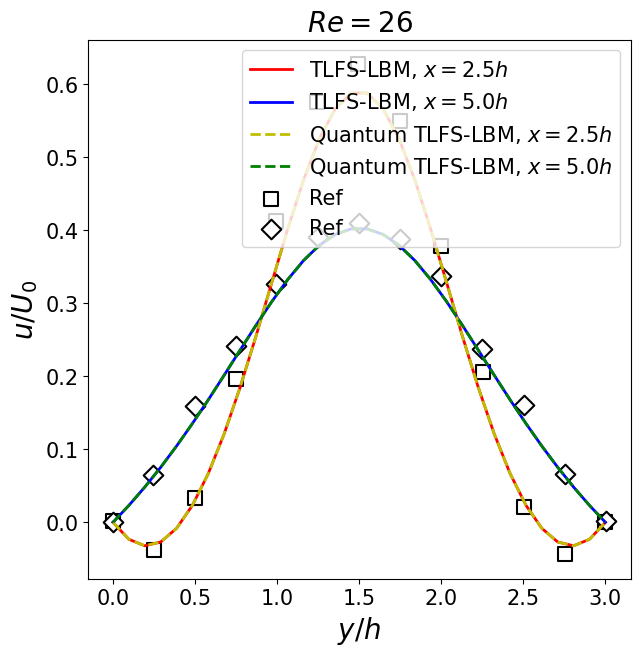

In [ ]:
fig = plt.figure(figsize=(7, 7))
plt.xlabel('$y/h$', size=20)
plt.ylabel('$u/U_0$', size=20)
plt.title('$Re=26$', size=20)
plt.tick_params(labelsize=15)

x_1 = Y[:,-1]
plt.plot(x_1,(10*(u[:,17,0])),'r-',label = "TLFS-LBM, $x = 2.5h$",linewidth = 2,)
plt.plot(x_1,(10*(u[:,22,0])),'b-',label = "TLFS-LBM, $x = 5.0h$",linewidth = 2,)

plt.plot(x_1,(10*(Psi_qlbm1[t,:,17])),'y--',label = "Quantum TLFS-LBM, $x = 2.5h$",linewidth = 2,)
plt.plot(x_1,(10*(Psi_qlbm1[t,:,22])),'g--',label = "Quantum TLFS-LBM, $x = 5.0h$",linewidth = 2,)

L1 = np.array([0, 
0.2507739938080496, 
0.5015479876160991,
0.7476780185758514,
0.9938080495356039,
1.2445820433436534,
1.495356037151703,
1.7461300309597527,
1.996904024767802,
2.2523219814241493,
2.5030959752321986,
2.7538699690402484,
3.0000000000000004])

L2 = np.array([0.001151631477927073
, -0.03810010517996465
, 0.033204780043141646
, 0.19664196621167918
, 0.41190256888693455
, 0.5753379723442059
, 0.6270651224425522
, 0.5498095470130673
, 0.37812019039356326
, 0.2052774195848659
, 0.020920116708164183
, -0.043667512464122815
, 0])
L3 = np.array([0, 
0.24613003095975244, 
0.496904024767802, 
0.7476780185758514, 
0.9938080495356039, 
1.2492260061919505,
1.5000000000000002, 
1.7507739938080495,
1.996904024767802, 
2.247678018575852, 
2.5030959752321986, 
2.7538699690402484, 
3.0046439628482977])
L4 = np.array([0
, 0.06439687906681002
, 0.15873439384845767
, 0.2415555938508347
, 0.3266818395203318
, 0.3899235216866826
, 0.40940499040307105
, 0.38742772591408525
, 0.33781308866611603
, 0.23752488367808988
, 0.16026752553733892
, 0.06573747793894813
, 0.0011498487666609103])

plt.scatter(L1, L2, c='w',edgecolors='k',marker='s',s = 100,linewidths=1.5,clip_on = False,label = "Ref")
plt.scatter(L3, L4, c='w',edgecolors='k',marker='D',s = 100,linewidths=1.5,clip_on = False,label = "Ref")
plt.legend(loc=0,ncol=1,fontsize=15)
#plt.savefig('plot_u_y.png', format='png', dpi=200)
plt.show()

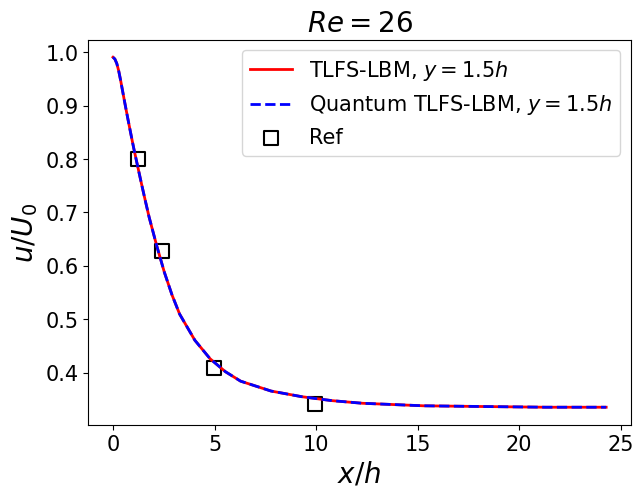

In [ ]:
fig = plt.figure(figsize=(7, 5))
plt.xlabel('$x/h$', size=20)
plt.ylabel('$u/U_0$', size=20)
plt.title('$Re=26$', size=20)
plt.tick_params(labelsize=15)

y_1 = X[-1,:]
plt.plot(y_1,(10*(u[15,:,0]+u[15,:,0])/2),'r-',label = "TLFS-LBM, $y = 1.5h$",linewidth = 2,)
plt.plot(y_1,(10*(((Psi_qlbm1[t,15,:]+Psi_qlbm1[t,16,:])/2))),'b--',label ="Quantum TLFS-LBM, $y = 1.5h$",linewidth = 2,)

L11 = np.array([1.2173913043478262, 
2.4347826086956523, 
4.956521739130434, 
9.956521739130434])
L22 = np.array([0.7992264318001773
, 0.6267486835360456
, 0.4078288829861598
, 0.3404119483666528])
plt.scatter(L11, L22, c='w',edgecolors='k',marker='s',s = 100,linewidths=1.5,clip_on = False,label = "Ref")
plt.legend(loc=0,ncol=1,fontsize=15)
#plt.savefig('plot_u_x.png', format='png', dpi=200)
plt.show()